## Setup

In [29]:
import pickle
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

# Make src/ importable
sys.path.insert(0, str(Path.cwd().parent))

from src.data_loader import read_csv_from_blob, load_entsoe_token
from src.dataset import assemble_dataset
from src.train import predict_next_day, train_per_horizon_models
from src.features import build_supervised_dataset

STORAGE_ACCOUNT = "sagreekdamdevweu"
GATE_CLOSURE_HOUR = 12
print("Setup complete")

Setup complete


## Load processed data from blob

In [30]:
print("Loading data from blob...")

dam = read_csv_from_blob(STORAGE_ACCOUNT, "processed", "dam_prices/full.csv")
load = read_csv_from_blob(STORAGE_ACCOUNT, "processed", "load_forecast/full.csv")
renewable = read_csv_from_blob(STORAGE_ACCOUNT, "processed", "renewable_forecast/full.csv")

print(f"DAM:        {len(dam)} rows, {dam.index.min()} → {dam.index.max()}")
print(f"Load:       {len(load)} rows, {load.index.min()} → {load.index.max()}")
print(f"Renewable:  {len(renewable)} rows, {renewable.index.min()} → {renewable.index.max()}")

# Also show data column names so we're sure of structure
print(f"\nDAM columns:       {list(dam.columns)}")
print(f"Load columns:      {list(load.columns)}")
print(f"Renewable columns: {list(renewable.columns)}")

Loading data from blob...
DAM:        29424 rows, 2022-12-31 22:00:00+00:00 → 2026-05-10 21:00:00+00:00
Load:       29471 rows, 2022-12-31 22:00:00+00:00 → 2026-05-12 20:00:00+00:00
Renewable:  29471 rows, 2022-12-31 22:00:00+00:00 → 2026-05-12 20:00:00+00:00

DAM columns:       ['price_eur_mwh']
Load columns:      ['load_forecast_mw']
Renewable columns: ['solar', 'wind_onshore']


## Train a fresh model

In [21]:
print("Assembling training dataset (inner join — drops misaligned rows)...")
prices_train, exog_train = assemble_dataset(dam, load, renewable, join="inner")
print(f"Training data: {len(prices_train)} rows")
print(f"Range: {prices_train.index.min()} → {prices_train.index.max()}")

print("\nTraining 24 per-horizon LightGBM models...")
lgbm_params = {
    "n_estimators": 200,
    "learning_rate": 0.05,
    "num_leaves": 63,
    "min_child_samples": 20,
    "random_state": 42,
    "verbose": -1,
}

lgbm_params = None 

result = train_per_horizon_models(
    prices_train,
    exog=exog_train,
    gate_closure_hour=GATE_CLOSURE_HOUR,
    horizons=tuple(range(0, 24)),
    same_hour_lag_days=(1, 2, 7),
    context_window=1,
    test_days=30,
    lgbm_params=lgbm_params,
)

print("Training complete!\n")
print(result.summary())

Assembling training dataset (inner join — drops misaligned rows)...
Training data: 29424 rows
Range: 2022-12-31 22:00:00+00:00 → 2026-05-10 21:00:00+00:00

Training 24 per-horizon LightGBM models...
Training complete!

TrainResult Summary
  Models trained:    24 per-horizon LightGBM models
  Features:          38
  Gate closure:      12:00
  Overall test MAE:  18.32 EUR/MWh
  Overall test RMSE: 24.16 EUR/MWh
  Best horizon:      h= 8 (MAE 14.01)
  Worst horizon:     h=18 (MAE 29.84)


## Inspect the trained model

In [ ]:
print(f"Feature names ({len(result.feature_names)}):")
for f in result.feature_names:
    print(f"  - {f}")

print(f"\nPer-horizon metrics:")
print(result.metrics_per_horizon.to_string(index=False))

## Predict May 10

In [22]:
# Reassemble with outer join so we can include exog for tomorrow's hours
prices, exog = assemble_dataset(dam, load, renewable, join="outer")

# Simulate "data as of May 9, 12:00 Athens" (= May 9 09:00 UTC in summer time)
forecast_time_may9_utc = pd.Timestamp("2026-05-09 09:00:00+00:00")
print(f"Simulated forecast time: {forecast_time_may9_utc} UTC")
print(f"                       ≈ {forecast_time_may9_utc.tz_convert('Europe/Athens')} Athens")

# Mask out all prices after that time (we couldn't have seen them at inference)
prices_at_may9 = prices.copy()
prices_at_may9[prices_at_may9.index > forecast_time_may9_utc] = np.nan

print(f"\nLast known price: {prices_at_may9.dropna().index.max()}")

# Predict
forecast_may10 = predict_next_day(
    result, prices_at_may9, exog=exog, forecast_time=forecast_time_may9_utc
)

print(f"\nForecast for May 10:")
print(f"Range: {forecast_may10.index.min()} → {forecast_may10.index.max()}")
print(forecast_may10.to_frame(name="predicted"))

Simulated forecast time: 2026-05-09 09:00:00+00:00 UTC
                       ≈ 2026-05-09 12:00:00+03:00 Athens

Last known price: 2026-05-09 09:00:00+00:00

Forecast for May 10:
Range: 2026-05-09 21:00:00+00:00 → 2026-05-10 20:00:00+00:00
                            predicted
2026-05-09 21:00:00+00:00  121.782359
2026-05-09 22:00:00+00:00  101.629681
2026-05-09 23:00:00+00:00  120.531808
2026-05-10 00:00:00+00:00  134.190289
2026-05-10 01:00:00+00:00  122.935342
2026-05-10 02:00:00+00:00  116.270041
2026-05-10 03:00:00+00:00  126.390631
2026-05-10 04:00:00+00:00  119.570405
2026-05-10 05:00:00+00:00   94.921952
2026-05-10 06:00:00+00:00   48.275026
2026-05-10 07:00:00+00:00    9.068724
2026-05-10 08:00:00+00:00    2.632922
2026-05-10 09:00:00+00:00    3.924236
2026-05-10 10:00:00+00:00   21.993591
2026-05-10 11:00:00+00:00   24.417722
2026-05-10 12:00:00+00:00   57.508765
2026-05-10 13:00:00+00:00   85.976772
2026-05-10 14:00:00+00:00  111.004444
2026-05-10 15:00:00+00:00  137.187264

## Compare predicted vs actual May 10

In [23]:
# Reassemble with outer join so we can include exog for tomorrow's hours
prices, exog = assemble_dataset(dam, load, renewable, join="outer")

# Simulate "data as of May 9, 12:00 Athens" (= May 9 09:00 UTC in summer time)
forecast_time_may9_utc = pd.Timestamp("2026-05-09 09:00:00+00:00")
print(f"Simulated forecast time: {forecast_time_may9_utc} UTC")
print(f"                       ≈ {forecast_time_may9_utc.tz_convert('Europe/Athens')} Athens")

# Mask out all prices after that time (we couldn't have seen them at inference)
prices_at_may9 = prices.copy()
prices_at_may9[prices_at_may9.index > forecast_time_may9_utc] = np.nan

print(f"\nLast known price: {prices_at_may9.dropna().index.max()}")

# Predict
forecast_may10 = predict_next_day(
    result, prices_at_may9, exog=exog, forecast_time=forecast_time_may9_utc
)

print(f"\nForecast for May 10:")
print(f"Range: {forecast_may10.index.min()} → {forecast_may10.index.max()}")
print(forecast_may10.to_frame(name="predicted"))

Simulated forecast time: 2026-05-09 09:00:00+00:00 UTC
                       ≈ 2026-05-09 12:00:00+03:00 Athens

Last known price: 2026-05-09 09:00:00+00:00

Forecast for May 10:
Range: 2026-05-09 21:00:00+00:00 → 2026-05-10 20:00:00+00:00
                            predicted
2026-05-09 21:00:00+00:00  121.782359
2026-05-09 22:00:00+00:00  101.629681
2026-05-09 23:00:00+00:00  120.531808
2026-05-10 00:00:00+00:00  134.190289
2026-05-10 01:00:00+00:00  122.935342
2026-05-10 02:00:00+00:00  116.270041
2026-05-10 03:00:00+00:00  126.390631
2026-05-10 04:00:00+00:00  119.570405
2026-05-10 05:00:00+00:00   94.921952
2026-05-10 06:00:00+00:00   48.275026
2026-05-10 07:00:00+00:00    9.068724
2026-05-10 08:00:00+00:00    2.632922
2026-05-10 09:00:00+00:00    3.924236
2026-05-10 10:00:00+00:00   21.993591
2026-05-10 11:00:00+00:00   24.417722
2026-05-10 12:00:00+00:00   57.508765
2026-05-10 13:00:00+00:00   85.976772
2026-05-10 14:00:00+00:00  111.004444
2026-05-10 15:00:00+00:00  137.187264

## Compare predicted vs actual May 10

In [24]:
# Get actuals
actuals_may10 = prices.loc[forecast_may10.index]

comparison_may10 = pd.DataFrame({
    "predicted": forecast_may10.values,
    "actual": actuals_may10.values,
}, index=forecast_may10.index)

comparison_may10["error"] = comparison_may10["actual"] - comparison_may10["predicted"]
comparison_may10["abs_error"] = comparison_may10["error"].abs()
comparison_may10["hour_athens"] = comparison_may10.index.tz_convert("Europe/Athens").hour

print(f"=== May 10 forecast vs actual ===")
print(comparison_may10.to_string())
print(f"\nMAE:   {comparison_may10['abs_error'].mean():.2f} EUR/MWh")
print(f"RMSE:  {np.sqrt((comparison_may10['error']**2).mean()):.2f} EUR/MWh")
print(f"Worst hour: UTC {comparison_may10['abs_error'].idxmax().hour:02d} "
      f"(Athens {int(comparison_may10.loc[comparison_may10['abs_error'].idxmax(), 'hour_athens']):02d}), "
      f"error = {comparison_may10['abs_error'].max():.2f}")

=== May 10 forecast vs actual ===
                            predicted    actual      error  abs_error  hour_athens
2026-05-09 21:00:00+00:00  121.782359  174.3050  52.522641  52.522641            0
2026-05-09 22:00:00+00:00  101.629681  162.0250  60.395319  60.395319            1
2026-05-09 23:00:00+00:00  120.531808  148.3775  27.845692  27.845692            2
2026-05-10 00:00:00+00:00  134.190289  133.8100  -0.380289   0.380289            3
2026-05-10 01:00:00+00:00  122.935342  131.7625   8.827158   8.827158            4
2026-05-10 02:00:00+00:00  116.270041  134.4425  18.172459  18.172459            5
2026-05-10 03:00:00+00:00  126.390631  140.0425  13.651869  13.651869            6
2026-05-10 04:00:00+00:00  119.570405  122.6400   3.069595   3.069595            7
2026-05-10 05:00:00+00:00   94.921952  107.0625  12.140548  12.140548            8
2026-05-10 06:00:00+00:00   48.275026   52.2225   3.947474   3.947474            9
2026-05-10 07:00:00+00:00    9.068724   -0.0025  -9.0

## Predict May 11 (using data through May 10 noon Athens)

In [25]:
forecast_time_may10_utc = pd.Timestamp("2026-05-10 09:00:00+00:00")
print(f"Simulated forecast time: {forecast_time_may10_utc} UTC")

# Mask after May 10 noon Athens
prices_at_may10 = prices.copy()
prices_at_may10[prices_at_may10.index > forecast_time_may10_utc] = np.nan

print(f"Last known price: {prices_at_may10.dropna().index.max()}")

# Predict
forecast_may11 = predict_next_day(
    result, prices_at_may10, exog=exog, forecast_time=forecast_time_may10_utc
)

print(f"\nForecast for May 11:")
print(forecast_may11.to_frame(name="predicted"))

Simulated forecast time: 2026-05-10 09:00:00+00:00 UTC
Last known price: 2026-05-10 09:00:00+00:00

Forecast for May 11:
                            predicted
2026-05-10 21:00:00+00:00  118.137936
2026-05-10 22:00:00+00:00  127.104680
2026-05-10 23:00:00+00:00  115.823232
2026-05-11 00:00:00+00:00  126.660622
2026-05-11 01:00:00+00:00  127.473308
2026-05-11 02:00:00+00:00  136.062443
2026-05-11 03:00:00+00:00  148.758034
2026-05-11 04:00:00+00:00  148.429854
2026-05-11 05:00:00+00:00  121.772456
2026-05-11 06:00:00+00:00   66.636231
2026-05-11 07:00:00+00:00   22.108829
2026-05-11 08:00:00+00:00   17.774955
2026-05-11 09:00:00+00:00   18.755842
2026-05-11 10:00:00+00:00   34.587986
2026-05-11 11:00:00+00:00   69.620863
2026-05-11 12:00:00+00:00   83.014455
2026-05-11 13:00:00+00:00   95.207056
2026-05-11 14:00:00+00:00  143.808957
2026-05-11 15:00:00+00:00  127.360946
2026-05-11 16:00:00+00:00  168.623110
2026-05-11 17:00:00+00:00  191.483938
2026-05-11 18:00:00+00:00  160.097176
2026-

## Fetch actual May 11 from ENTSO-E and compare

In [26]:
from src.data_loader import fetch_dam_prices
from src.processing import ensure_hourly

print("Fetching actual May 11 prices from ENTSO-E...")

# Fetch a 2-day window covering all of May 11
start = pd.Timestamp("2026-05-10", tz="Europe/Athens")
end = pd.Timestamp("2026-05-12", tz="Europe/Athens")

actual_dam_may11 = fetch_dam_prices(start=start, end=end, country_code="GR")
actual_dam_may11 = ensure_hourly(actual_dam_may11)
actual_dam_may11.index = actual_dam_may11.index.tz_convert("UTC")
print(f"Fetched {len(actual_dam_may11)} rows from {actual_dam_may11.index.min()} to {actual_dam_may11.index.max()}")

# Slice to just May 11 (UTC offset depends on DST; in summer May = UTC+3)
may11_start_utc = pd.Timestamp("2026-05-10 21:00:00+00:00")  # = May 11 00:00 Athens
may11_end_utc = pd.Timestamp("2026-05-11 21:00:00+00:00")    # = May 12 00:00 Athens

actuals_may11 = actual_dam_may11[
    (actual_dam_may11.index >= may11_start_utc)
    & (actual_dam_may11.index < may11_end_utc)
]
print(f"May 11 (Athens day, UTC indexed): {len(actuals_may11)} rows")

# Align forecast and actuals
comparison_may11 = pd.DataFrame({
    "predicted": forecast_may11.values,
    "actual": actuals_may11.reindex(forecast_may11.index).values,
}, index=forecast_may11.index)

comparison_may11["error"] = comparison_may11["actual"] - comparison_may11["predicted"]
comparison_may11["abs_error"] = comparison_may11["error"].abs()
comparison_may11["hour_athens"] = comparison_may11.index.tz_convert("Europe/Athens").hour

print(f"\n=== May 11 forecast vs actual ===")
print(comparison_may11.to_string())
print(f"\nMAE:   {comparison_may11['abs_error'].mean():.2f} EUR/MWh")
print(f"RMSE:  {np.sqrt((comparison_may11['error']**2).mean()):.2f} EUR/MWh")
print(f"Worst hour: UTC {comparison_may11['abs_error'].idxmax().hour:02d} "
      f"(Athens {int(comparison_may11.loc[comparison_may11['abs_error'].idxmax(), 'hour_athens']):02d}), "
      f"error = {comparison_may11['abs_error'].max():.2f}")

Fetching actual May 11 prices from ENTSO-E...
Fetched 49 rows from 2026-05-09 21:00:00+00:00 to 2026-05-11 21:00:00+00:00
May 11 (Athens day, UTC indexed): 24 rows

=== May 11 forecast vs actual ===
                            predicted    actual      error  abs_error  hour_athens
2026-05-10 21:00:00+00:00  118.137936  158.7250  40.587064  40.587064            0
2026-05-10 22:00:00+00:00  127.104680  136.6150   9.510320   9.510320            1
2026-05-10 23:00:00+00:00  115.823232  119.4850   3.661768   3.661768            2
2026-05-11 00:00:00+00:00  126.660622  117.5975  -9.063122   9.063122            3
2026-05-11 01:00:00+00:00  127.473308  119.5875  -7.885808   7.885808            4
2026-05-11 02:00:00+00:00  136.062443  143.5675   7.505057   7.505057            5
2026-05-11 03:00:00+00:00  148.758034  166.1125  17.354466  17.354466            6
2026-05-11 04:00:00+00:00  148.429854  173.5775  25.147646  25.147646            7
2026-05-11 05:00:00+00:00  121.772456  121.7500  -0.02

## Predict May 12 / "tomorrow"

In [27]:
# No masking — use all data we currently have (this is what production runs)
# forecast_time defaults to the latest gate_closure_hour timestamp in prices
print("Production-style prediction (no masking)...")
forecast_production = predict_next_day(result, prices, exog=exog)

forecast_date = forecast_production.index.min().tz_convert("Europe/Athens").date()
print(f"\nProduction forecast for: {forecast_date} (Athens)")
print(forecast_production.to_frame(name="predicted_eur_mwh"))

Production-style prediction (no masking)...

Production forecast for: 2026-05-13 (Athens)
                           predicted_eur_mwh
2026-05-13 00:00:00+00:00          79.462371
2026-05-13 01:00:00+00:00          62.198956
2026-05-13 02:00:00+00:00          56.138142
2026-05-13 03:00:00+00:00          37.308736
2026-05-13 04:00:00+00:00         100.187084
2026-05-13 05:00:00+00:00         106.865639
2026-05-13 06:00:00+00:00          85.183232
2026-05-13 07:00:00+00:00          77.206892
2026-05-13 08:00:00+00:00          62.585371
2026-05-13 09:00:00+00:00          79.283345
2026-05-13 10:00:00+00:00          52.714091
2026-05-13 11:00:00+00:00          44.252757
2026-05-13 12:00:00+00:00          59.016444
2026-05-13 13:00:00+00:00          77.105158
2026-05-13 14:00:00+00:00         127.019168
2026-05-13 15:00:00+00:00         162.516689
2026-05-13 16:00:00+00:00         170.943606
2026-05-13 17:00:00+00:00         196.419069
2026-05-13 18:00:00+00:00         206.376288
2026-05-13

## Visualize all three days

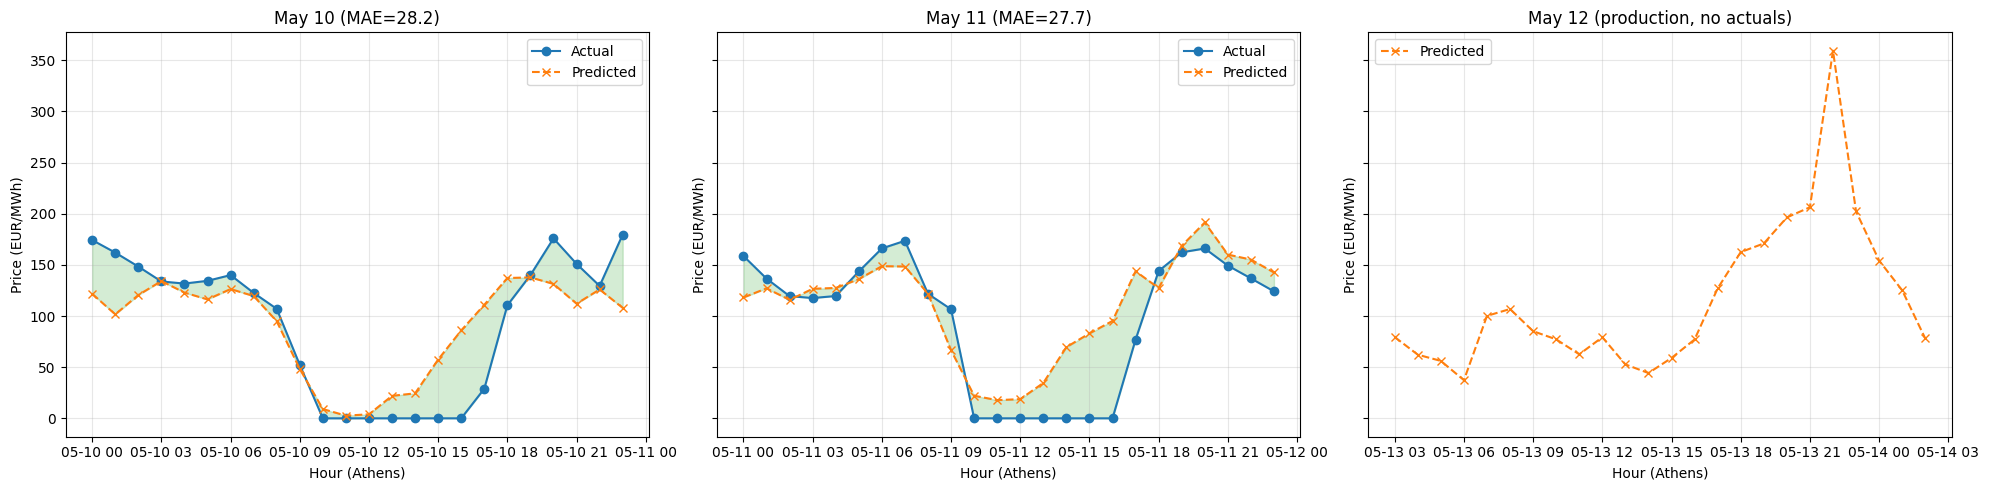

In [28]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=True)

for ax, (df, label) in zip(
    axes,
    [
        (comparison_may10, "May 10"),
        (comparison_may11, "May 11"),
        (None, "May 12 (production, no actuals)"),
    ],
):
    if df is not None:
        athens_idx = df.index.tz_convert("Europe/Athens")
        ax.plot(athens_idx, df["actual"], "o-", label="Actual", color="C0")
        ax.plot(athens_idx, df["predicted"], "x--", label="Predicted", color="C1")
        ax.fill_between(athens_idx, df["actual"], df["predicted"], 
                        alpha=0.2, color="C2")
        mae = df["abs_error"].mean()
        ax.set_title(f"{label} (MAE={mae:.1f})")
    else:
        athens_idx = forecast_production.index.tz_convert("Europe/Athens")
        ax.plot(athens_idx, forecast_production.values, "x--", 
                label="Predicted", color="C1")
        ax.set_title(label)
    
    ax.set_xlabel("Hour (Athens)")
    ax.set_ylabel("Price (EUR/MWh)")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()